## This notebook serves the purpose to test different filter configuration for preprocessing

In [1]:
# libraries
import os
import numpy as np
import pandas as pd
from hampel import hampel
from scipy.signal import savgol_filter
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# modules
from src.core import Participant
from src.config import config

### 1) Define the filters (extracted from src/utils.py)

In [2]:
def sandbox_hampel(data_arr, window, n_sigma):
    data_series = pd.Series(data_arr)
    interp_data = data_series.interpolate(method='linear', limit_direction='both').to_numpy()
    try:
        return hampel(interp_data, window, n_sigma).filtered_data
    except Exception:
        return interp_data

def sandbox_kalman(data_arr, dt, Q_scale, R_scale):
    valid_indices = np.where(~np.isnan(data_arr))[0]
    if not valid_indices.size:
        return np.full_like(data_arr, np.nan)

    dim_x, dim_z = 3, 1
    initial_pos = data_arr[valid_indices[0]]

    kf = KalmanFilter(dim_x=dim_x, dim_z=dim_z)
    kf.x = np.array([[initial_pos], [0.], [0.]])
    kf.P = np.eye(dim_x) * 1000.0
    kf.H = np.array([[1., 0., 0.]])
    kf.R = np.array([[R_scale]])
    kf.F = np.array([[1., dt, 0.5 * dt ** 2],
                     [0., 1., dt],
                     [0., 0., 1.]])
    kf.Q = Q_discrete_white_noise(dim=dim_x, dt=dt, var=Q_scale, block_size=1)

    filtered_pos = np.zeros(len(data_arr))
    for i in range(len(data_arr)):
        z_k = data_arr[i]
        kf.predict()
        if not np.isnan(z_k):
            kf.update(np.array([[z_k]]))
        filtered_pos[i] = kf.x[0, 0]
    return filtered_pos

def sandbox_savgol(data_arr, window, poly):
    return savgol_filter(data_arr, window, poly)

### 2) Define the filter plot function

In [5]:
def plot_filter_sandbox(raw_sig: np.ndarray, hampel_sig: np.ndarray, kalman_sig: np.ndarray, savgol_sig: np.ndarray,
                        metric_name: str, framerate: float = 90.0) -> None:
    """
    Visualizes the preprocessing pipeline on any 1D movement signal.

    Args:
        raw_sig (np.ndarray): Raw signal (1D array).
        hampel_sig (np.ndarray): 1st filtering step providing a Hampel filtered signal.
        kalman_sig (np.ndarray): 2nd filtering step providing a Kalman filtered signal.
        savgol_sig (np.ndarray): 3rd filtering step providing a Savitzky-Golay filtered signal.
        metric_name (str): Name of the landmark to visualize. optional.
        framerate (float): Framerate of the raw signal.

    Returns:
        None
    """
    # x-axis
    t = np.linspace(0.0, len(raw_sig) * (1 / framerate), num=len(raw_sig))

    # pass a slice or the whole signal to process
    mask = t >= 0
    t_slice = t[mask]
    raw_slice = raw_sig[mask]
    hampel_slice = hampel_sig[mask]
    kalman_slice = kalman_sig[mask]
    savgol_slice = savgol_sig[mask]

    # filter stage colors
    colors = {
        'raw': '#1f77b4',       # blue
        'hampel': '#ff7f0e',    # orange
        'kalman': '#2ca02c',    # green
        'savgol': '#d62728',    # red
        'residual': '#aaaaaa'   # grey
    }

    # figure setup
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(f'Preprocessing Sandbox: {metric_name}', fontsize=16, fontweight='bold')

    # gridspec setup
    outer_grid = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.2)

    # function handling comparison plots setup
    def create_comparison_plot(cell, title, x_data, sig1_data, sig2_data, label1, label2, color1, color2, show_residual=True):
        if show_residual:
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=cell, height_ratios=[3, 1], hspace=0.0)
            ax_main = fig.add_subplot(inner_grid[0])
            ax_res = fig.add_subplot(inner_grid[1], sharex=ax_main)
        else:
            ax_main = fig.add_subplot(cell)
            ax_res = None

        ax_main.set_title(title, fontsize=12, pad=10)

        # plot signal1 (sig1_data) - lower alpha than filtered overlay
        if sig1_data is not None:
            ax_main.plot(x_data, sig1_data, label=label1, color=color1, alpha=0.5 if sig2_data is not None else 1.0)

        # plot signal2 (sig2_data) - filtered overlay
        if sig2_data is not None:
            ax_main.plot(x_data, sig2_data, label=label2, color=color2, linewidth=1.5)

        ax_main.set_ylabel('Amplitude', fontsize=9)
        ax_main.legend(loc='upper right', fontsize=8)
        ax_main.grid(True, alpha=0.1)

        if ax_res:
            plt.setp(ax_main.get_xticklabels(), visible=False)
            residual = sig1_data - sig2_data
            ax_res.plot(x_data, residual, color=colors['residual'], linewidth=1)
            ax_res.fill_between(x_data, residual, 0, color=colors['residual'], alpha=0.3)
            ax_res.set_ylabel('Diff', fontsize=8)
            ax_res.grid(True, alpha=0.1)

            limit = max(abs(np.min(residual)), abs(np.max(residual))) * 1.1
            if limit == 0: limit = 0.1
            ax_res.set_ylim(-limit, limit)
            ax_res.set_xlabel('Time [s]')
        else:
            ax_main.set_xlabel('Time [s]')

    # row 1
    create_comparison_plot(outer_grid[0, 0], '1) Raw Input', t_slice, raw_slice, None, 'Raw', None, colors['raw'], None, show_residual=False)
    create_comparison_plot(outer_grid[0, 1], '2) Despiking: Raw vs Hampel', t_slice, raw_slice, hampel_slice, 'Raw', 'Hampel', colors['raw'], colors['hampel'])

    # row 2
    create_comparison_plot(outer_grid[1, 0], '3) Denoising: Hampel vs Kalman', t_slice, hampel_slice, kalman_slice, 'Hampel', 'Kalman', colors['hampel'], colors['kalman'])
    create_comparison_plot(outer_grid[1, 1], '4) Smoothing: Kalman vs Savgol', t_slice, kalman_slice, savgol_slice, 'Kalman', 'Savgol', colors['kalman'], colors['savgol'])

    # row 3
    create_comparison_plot(outer_grid[2, :], '5) End-to-End: Raw vs Final Savgol', t_slice, raw_slice, savgol_slice, 'Raw', 'Final Savgol', colors['raw'], colors['savgol'])

    #plt.tight_layout()
    plt.show()

### 3) Load a specific landmark time series

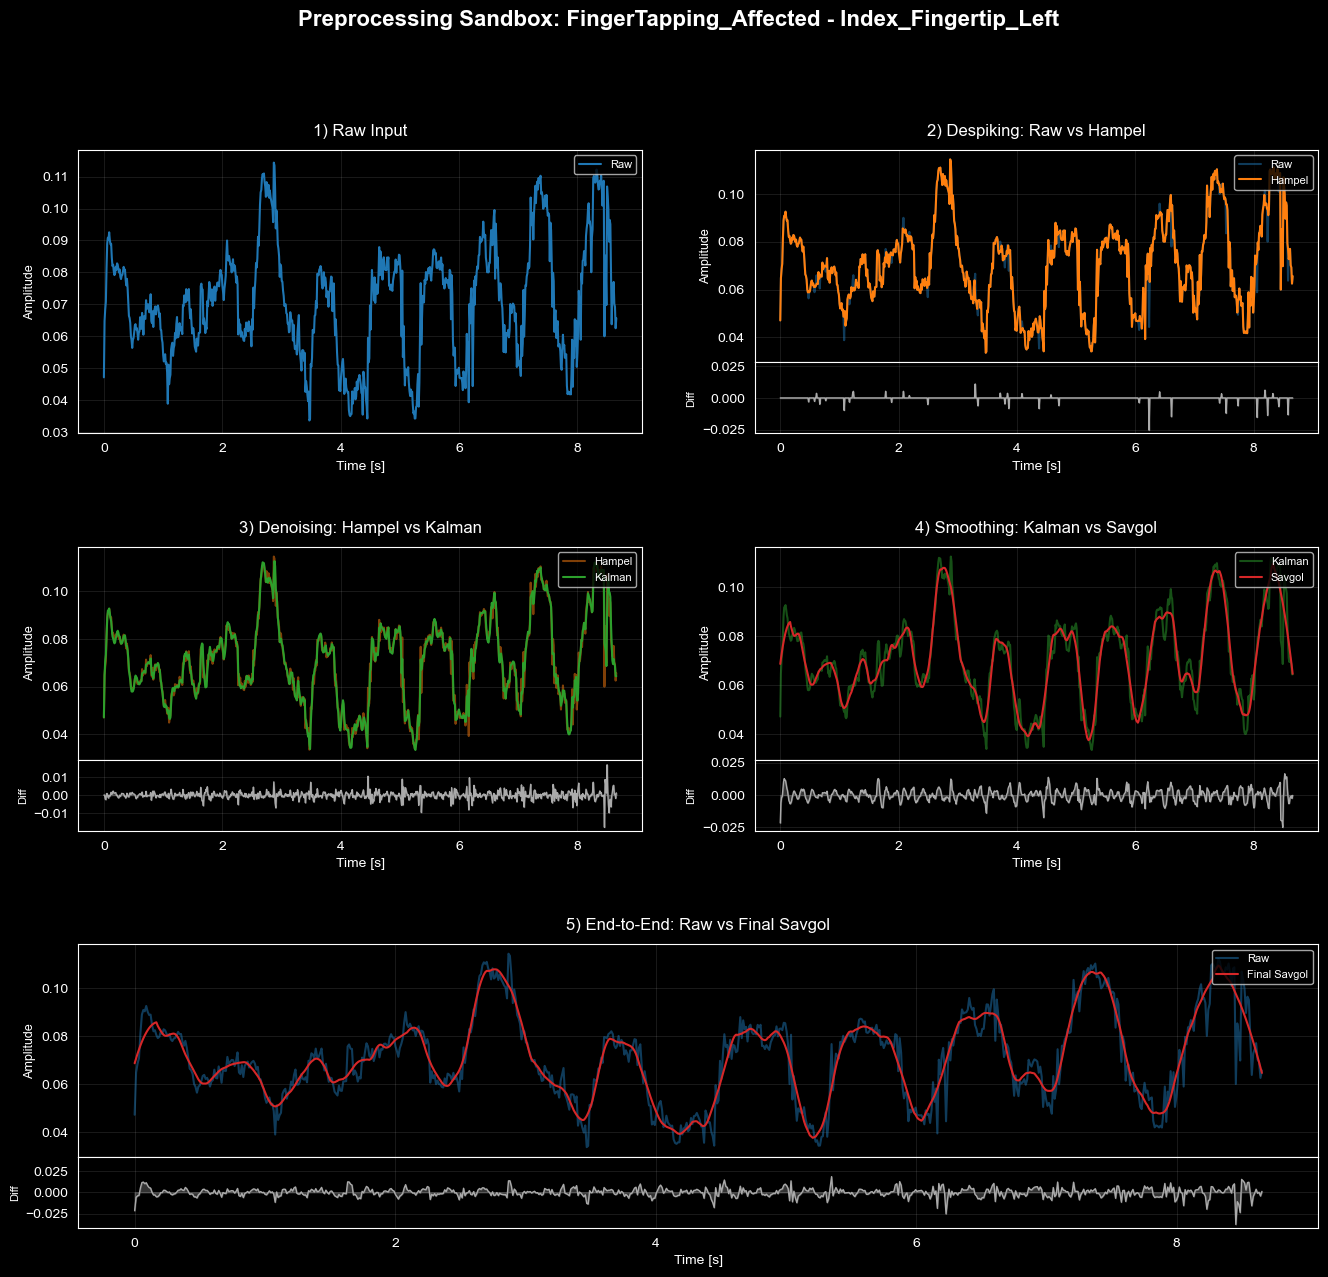

In [6]:
# project path
project_path: str = config['project_paths']['project_path']

# load a single participant
p = Participant.load(os.path.join(project_path, 'data/03_processed/P001_T1.pickle'))

# select an exercise
ex = p.exercises['FingerTapping_Affected']

# extract a specific 1D array to tune (e.g., the x-axis of the Index fingertip)
raw_1d_signal = ex.raw_hand_landmarks['ftip12'][0]

# -------------------- Change these parameters to see their filtering effect in the plot below --------------------
fps = 90.0                          # Default: 90.0

# Hampel settings
h_window = 7                        # Default: 7
h_sigma = 2.0                       # Default: 2.0

# Kalman settings
k_Q = 100.0                         # Default: 100.0
k_R = 0.0001                        # Default: 0.0001

# Savgol settings
s_window = 31                        # Default: 9
s_poly = 2                          # Default: 2

# apply parameters and plot time series
sig_hampel = sandbox_hampel(raw_1d_signal, h_window, h_sigma)
sig_kalman = sandbox_kalman(sig_hampel, 1/fps, k_Q, k_R)
sig_savgol = sandbox_savgol(sig_kalman, s_window, s_poly)

plot_filter_sandbox(raw_sig=raw_1d_signal,
                    hampel_sig=sig_hampel,
                    kalman_sig=sig_kalman,
                    savgol_sig=sig_savgol,
                    metric_name='FingerTapping_Affected - Index_Fingertip_Left',
                    framerate=fps)